<a href="https://colab.research.google.com/github/abhinavverma0907/SOC-2026-Encryption-and-Decryption/blob/main/Week_0/Assignment_1/Q2_Rocket_Fuel_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Q2 — Rocket Fuel Data Analysis

## Mounted drive


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loaded the libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Loaded CSV

In [7]:
df = pd.read_csv('/content/drive/MyDrive/SOC-2026/Assignment-1/Q2/rocket_fuel_data.csv')

In [11]:
df.head(10)

,Fuel_Type,Temperature_C,Pressure_atm,Thrust_kN,Efficiency_Percent,Reactor_Stability,Oxygen_Level_Percent,Target_Planet
0,HydroX-9,3200.0,85.4,1450.0,88.5,Stable,21.3,Mars
1,NebulaFuel-3,2800.0,NaN,1200.0,76.2,Unstable,19.8,Venus
2,PlasmaCore-7,4100.0,120.3,2100.0,92.1,Stable,22.7,Jupiter
3,CryoBlast-2,1900.0,60.1,850.0,65.4,Stable,20.1,Moon
4,HydroX-9,3500.0,95.2,1680.0,90.3,Stable,NaN,Mars
5,NebulaFuel-3,2600.0,72.8,980.0,71.5,Unstable,18.9,Venus
6,TitanFlare-5,3800.0,110.5,1920.0,85.7,Stable,23.1,Saturn
7,CryoBlast-2,2100.0,65.3,920.0,68.2,Stable,20.5,Moon
8,PlasmaCore-7,4300.0,NaN,2350.0,94.6,Stable,24.0,Jupiter
9,HydroX-9,3100.0,82.7,1380.0,86.2,Stable,21.0,Mars


##Explore

In [26]:
df.shape

(40, 8)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Fuel_Type             40 non-null     object 
 1   Temperature_C         38 non-null     float64
 2   Pressure_atm          35 non-null     float64
 3   Thrust_kN             39 non-null     float64
 4   Efficiency_Percent    40 non-null     float64
 5   Reactor_Stability     40 non-null     object 
 6   Oxygen_Level_Percent  37 non-null     float64
 7   Target_Planet         40 non-null     object 
dtypes: float64(5), object(3)
memory usage: 2.6+ KB


In [28]:
df.describe()

,Temperature_C,Pressure_atm,Thrust_kN,Efficiency_Percent,Oxygen_Level_Percent
count,38.000000,35.00000,39.000000,40.000000,37.000000
mean,3256.578947,94.70000,1558.717949,82.322500,21.662162
std,823.897384,25.89774,597.931432,11.070879,2.003657
min,1800.000000,58.60000,790.000000,62.100000,18.500000
25%,2662.500000,71.50000,1000.000000,72.100000,20.000000
50%,3275.000000,88.10000,1470.000000,86.950000,21.300000
75%,3937.500000,119.30000,2090.000000,90.400000,23.200000
max,4600.000000,140.20000,2700.000000,97.000000,25.500000


In [30]:
df.isna().sum()

,0
Fuel_Type,0
Temperature_C,2
Pressure_atm,5
Thrust_kN,1
Efficiency_Percent,0
Reactor_Stability,0
Oxygen_Level_Percent,3
Target_Planet,0


In [32]:
df['Pressure_atm'] = df['Pressure_atm'].fillna(df['Pressure_atm'].median())

In [34]:
df['Temperature_C'] = df['Temperature_C'].fillna(df['Temperature_C'].mean())
df['Thrust_kN'] = df['Thrust_kN'].fillna(df['Thrust_kN'].mean())
df['Oxygen_Level_Percent'] = df['Oxygen_Level_Percent'].fillna(df['Oxygen_Level_Percent'].mean())

In [36]:
df.isna().sum()

,0
Fuel_Type,0
Temperature_C,0
Pressure_atm,0
Thrust_kN,0
Efficiency_Percent,0
Reactor_Stability,0
Oxygen_Level_Percent,0
Target_Planet,0


In [38]:
df_sorted_by_temp = df.sort_values('Temperature_C')
df_sorted_by_eff  = df.sort_values('Efficiency_Percent', ascending=False)

In [39]:
df['Power_Index'] = df['Thrust_kN'] * df['Efficiency_Percent']

In [42]:
df.head(8)

,Fuel_Type,Temperature_C,Pressure_atm,Thrust_kN,Efficiency_Percent,Reactor_Stability,Oxygen_Level_Percent,Target_Planet,Power_Index
0,HydroX-9,3200.0,85.4,1450.0,88.5,Stable,21.300000,Mars,128325.0
1,NebulaFuel-3,2800.0,88.1,1200.0,76.2,Unstable,19.800000,Venus,91440.0
2,PlasmaCore-7,4100.0,120.3,2100.0,92.1,Stable,22.700000,Jupiter,193410.0
3,CryoBlast-2,1900.0,60.1,850.0,65.4,Stable,20.100000,Moon,55590.0
4,HydroX-9,3500.0,95.2,1680.0,90.3,Stable,21.662162,Mars,151704.0
5,NebulaFuel-3,2600.0,72.8,980.0,71.5,Unstable,18.900000,Venus,70070.0
6,TitanFlare-5,3800.0,110.5,1920.0,85.7,Stable,23.100000,Saturn,164544.0
7,CryoBlast-2,2100.0,65.3,920.0,68.2,Stable,20.500000,Moon,62744.0


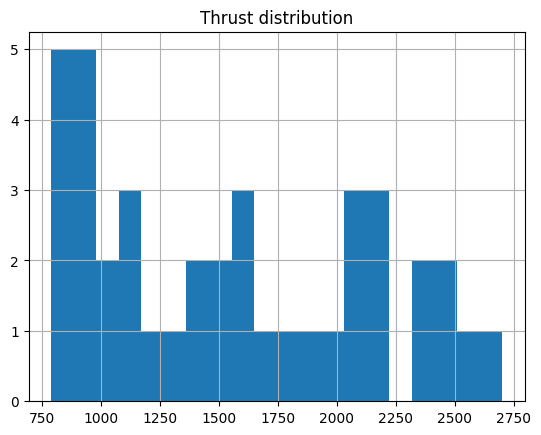

In [44]:
df['Thrust_kN'].hist(bins=20)
plt.title('Thrust distribution')
plt.show()

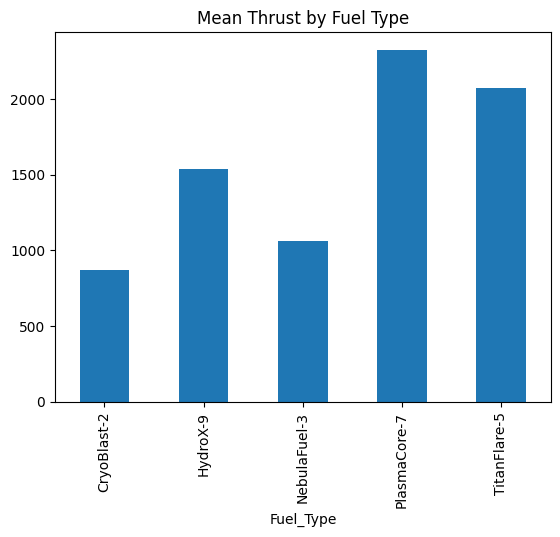

In [46]:
df.groupby('Fuel_Type')['Thrust_kN'].mean().plot(kind='bar')
plt.title('Mean Thrust by Fuel Type')
plt.show()

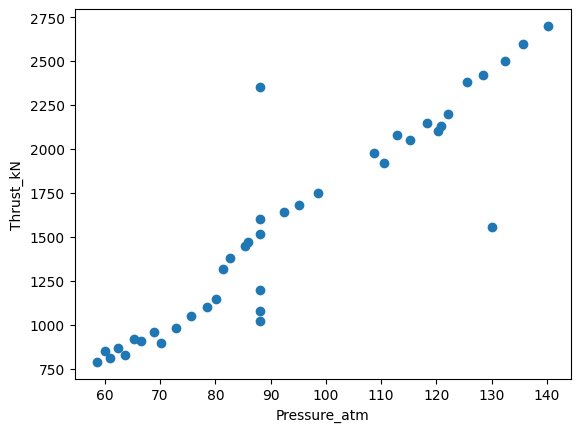

In [48]:
plt.scatter(df['Pressure_atm'], df['Thrust_kN'])
plt.xlabel('Pressure_atm')
plt.ylabel('Thrust_kN')
plt.show()

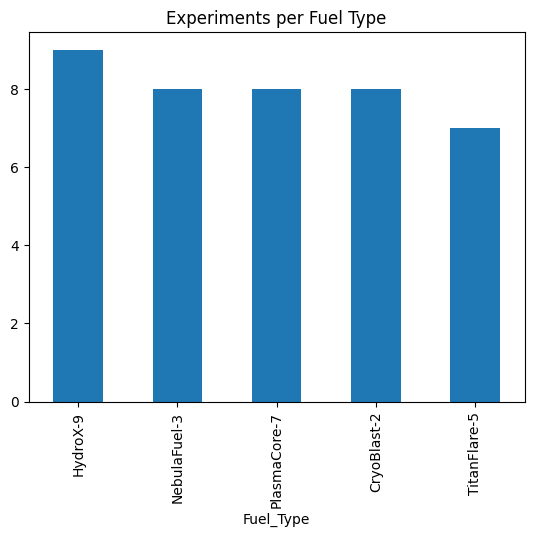

In [49]:
df['Fuel_Type'].value_counts().plot(kind='bar')
plt.title('Experiments per Fuel Type')
plt.show()